# Pipeline 



In [1]:
import math
import csv
import json
import numpy as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn
import optuna

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from typing import List, Optional, Dict
from itertools import product

from transformers import pipeline
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, make_scorer, recall_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, f_classif

from mlflow.tracking import MlflowClient
from xgboost import XGBClassifier




d:\Apps\anaconda\envs\langgraph-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## RiskCalculator

In [2]:
class RiskCalculator:
    def __init__(self, alpha=0.45, beta=0.25, gamma=0.30,
                 inter_alpha=0.5, inter_beta=0.3, inter_gamma=0.2,
                 pattern_alpha=0.4, pattern_beta=0.3, pattern_gamma=0.3):
        self.alpha = alpha
        self.beta  = beta
        self.gamma = gamma
        self.inter_alpha = inter_alpha
        self.inter_beta  = inter_beta
        self.inter_gamma = inter_gamma
        self.pattern_alpha = pattern_alpha
        self.pattern_beta  = pattern_beta
        self.pattern_gamma = pattern_gamma

    def compute_interaction_risk(self, features) -> float:
        return (
            self.inter_alpha * features["threat_score"] +
            self.inter_beta  * features["toxicity_score"] +
            self.inter_gamma * features["post_refusal"]
        )

    def compute_pattern_risk(self, features) -> float:
        return (
            self.pattern_alpha * features["topic_shift_score"] +
            self.pattern_beta  * features["cumulative_drift"] +
            self.pattern_gamma * features["drift_acceleration"]
        )

    def calculate_progressive_risk(self, features, prev_progressive: float) -> float:
        interaction_risk = self.compute_interaction_risk(features)
        pattern_risk     = self.compute_pattern_risk(features)
        progressive = (
            self.alpha * prev_progressive +
            self.beta  * interaction_risk +
            self.gamma * pattern_risk
        )
        return round(min(progressive, 1.0), 4)


## FeatureExtractor

In [12]:
import math
from typing import List


class FeatureExtractor:
    def __init__(self, toxicity_model, threat_model, embedding_model, refusal_model):
        self.toxicity_model  = toxicity_model
        self.threat_model    = threat_model
        self.embedding_model = embedding_model
        self.refusal_model   = refusal_model

        self.baseline_embedding = None
        self.turn_embeddings    = []
        self.drift_history      = []

    def reset(self):
        """Reset per-conversation state. Call between conversations."""
        self.baseline_embedding = None
        self.turn_embeddings    = []
        self.drift_history      = []

    def extract_features(
        self,
        user_msg: str,
        assistant_msg: str = "",
        user_msg2: str = "",
        assistant_msg2: str = "",
    ) -> dict:
        combined_text = f"{user_msg2} {assistant_msg2}".strip()

        # 1. Generate embedding for the current turn
        current_embed = self._embed(combined_text) if combined_text else []

        # 2. Calculate features BEFORE appending to history
        topic_shift_score  = self._get_topic_shift(current_embed)
        cumulative_drift   = self._get_cumulative_drift(current_embed)
        drift_acceleration = self._get_drift_acceleration(current_embed)

        # 3. Append to history AFTER computing features (so next turn can use this one)
        if current_embed:
            self.turn_embeddings.append(current_embed)
            if self.baseline_embedding is None:
                self.baseline_embedding = current_embed

        features = {
            "toxicity_score":     self._get_toxicity_score(combined_text),
            "threat_score":       self._get_threat_score(combined_text),
            "topic_shift_score":  topic_shift_score,
            "cumulative_drift":   cumulative_drift,
            "drift_acceleration": drift_acceleration,
            "post_refusal":       self._get_post_refusal(assistant_msg2),
        }
        return features

    def _get_topic_shift(self, current_embed: List[float]) -> float:
        """Cosine distance from the immediately previous turn."""
        if not current_embed or not self.turn_embeddings:
            return 0.0
        return round(self._cosine_distance(current_embed, self.turn_embeddings[-1]), 4)

    def _get_cumulative_drift(self, current_embed: List[float]) -> float:
        """Cosine distance from the very first turn (baseline)."""
        if not current_embed:
            return 0.0
        if self.baseline_embedding is None:
            self.drift_history.append(0.0)
            return 0.0

        drift = round(self._cosine_distance(current_embed, self.baseline_embedding), 4)
        self.drift_history.append(drift)
        return drift

    def _get_drift_acceleration(self, current_embed: List[float]) -> float:
        """
        How much FASTER the topic is drifting compared to the previous step.
        acceleration = recent_drift - earlier_drift  (positive = speeding up)

        BUG FIX: original code had (earlier - recent) which is deceleration,
        not acceleration.  We also clamp to 0 so the feature stays non-negative.
        """
        if not current_embed or len(self.turn_embeddings) < 2:
            return 0.0

        recent_drift  = self._cosine_distance(current_embed, self.turn_embeddings[-1])
        earlier_drift = self._cosine_distance(self.turn_embeddings[-1], self.turn_embeddings[-2])
        acceleration  = recent_drift - earlier_drift          

        return round( acceleration, 4)

    def _get_post_refusal(self, assistant_msg2: str) -> float:
        """Returns 1.0 if the assistant's message is classified as a refusal, else 0.0."""
        if not assistant_msg2:
            return 0.0
        assistant_emb  = self.embedding_model.encode([assistant_msg2])
        assistant_pred = self.refusal_model.predict(assistant_emb)[0]
        return float(assistant_pred) if assistant_pred != 0 else 0.0

    def _get_toxicity_score(self, text: str) -> float:
        if not text:
            return 0.0
        result = self.toxicity_model(text, truncation=True, max_length=512)[0]
        return result["score"] if result["label"] == "hate" else 1.0 - result["score"]

    def _get_threat_score(self, text: str) -> float:
        if not text:
            return 0.0
        result = self.threat_model(text, truncation=True, max_length=512)[0]
        return result["score"] if result["label"] == "LABEL_1" else 1.0 - result["score"]

    def _embed(self, text: str) -> List[float]:
        return self.embedding_model.encode(text).tolist()

    @staticmethod
    def _cosine_distance(a: List[float], b: List[float]) -> float:
        dot    = sum(x * y for x, y in zip(a, b))
        norm_a = math.sqrt(sum(x ** 2 for x in a))
        norm_b = math.sqrt(sum(x ** 2 for x in b))
        similarity = dot / (norm_a * norm_b + 1e-9)
        return 1.0 - similarity

## Pretrained Models

In [4]:
toxicity_model = pipeline(
    "text-classification",
    model="facebook/roberta-hate-speech-dynabench-r4-target",
    device="cpu",
)
threat_model = pipeline(
    "text-classification",
    model="tomh/toxigen_roberta",
    device="cpu",
)

sentence_model  = SentenceTransformer('all-MiniLM-L6-v2')
embedding_model = sentence_model


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 763.63it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: facebook/roberta-hate-speech-dynabench-r4-target
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 393/393 [00:00<00:00, 662.34it/s, Materializing param=roberta.encoder.layer.23.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: tomh/toxigen_roberta
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect 

## Refusal Model (train & load)

In [5]:

# df_refusal = pd.read_csv("data/train_refusal_data.csv")
# texts_r    = df_refusal["response"].tolist()
# labels_r   = df_refusal["label"].tolist()
# embeddings_r = sentence_model.encode(texts_r)

# X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
#     embeddings_r, labels_r, test_size=0.2, random_state=42
# )
# X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
#     X_train_r, y_train_r, test_size=0.25, random_state=42
# )

refusal_model = joblib.load("refusal_classifier.pkl")
threshold = 0.5


## Data — Scale AI

In [6]:
with open("data/raw/conversation_multiTurn_scaleAI.json", "r", encoding="utf-8") as f:
    dataset_scaleai = json.load(f)

multi_turn_ScaleAI = [item for item in dataset_scaleai if len(item["turns"])]
print(f"Found {len(multi_turn_ScaleAI)} Scale AI conversations")


Found 389 Scale AI conversations


In [11]:
all_rows = []

for conv_id, convo in enumerate(multi_turn_ScaleAI[:5]):
    turns = convo["turns"]
    prev_user      = ""
    prev_assistant = ""

    feature_extractor = FeatureExtractor(
        toxicity_model=toxicity_model,
        threat_model=threat_model,
        embedding_model=embedding_model,
        refusal_model=refusal_model,
    )

    for turn_id, turn in enumerate(turns):
        user_msg      = turn["attack_message"]
        assistant_msg = turn["target_response"]
        label         = turn["judge_result"]

        if turn_id == 0:
            features = feature_extractor.extract_features(
                user_msg="", assistant_msg="",
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )
        else:
            features = feature_extractor.extract_features(
                user_msg=prev_user, assistant_msg=prev_assistant,
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )

        all_rows.append({"conv_id": conv_id, "turn_id": turn_id, "label": label, **features})
        prev_user      = user_msg
        prev_assistant = assistant_msg

df_scale_ai = pd.DataFrame(all_rows)
# df_scale_ai.to_csv("data/cleaned_train_multi_turn_ScaleAI.csv", index=False)
df_scale_ai.head(8)


,conv_id,turn_id,label,toxicity_score,threat_score,topic_shift_score,cumulative_drift,drift_acceleration,post_refusal
0,0,0,0,0.001083,0.001200,0.0000,0.0000,0.0,0.0
1,0,1,1,0.012294,0.005953,0.3295,0.3295,0.0,0.0
2,1,0,0,0.043459,0.001669,0.0000,0.0000,0.0,1.0
3,1,1,0,0.000187,0.000589,0.6271,0.6271,0.0,1.0
4,1,2,0,0.000169,0.000650,0.4229,0.6814,0.0,1.0
5,1,3,1,0.000185,0.000643,0.4138,0.7257,0.0,0.0
6,2,0,0,0.001051,0.000894,0.0000,0.0000,0.0,0.0
7,2,1,1,0.001154,0.000630,0.2634,0.2634,0.0,1.0


## Data — Crescendomation

In [9]:
with open("data/multi_turn_conversations_from_crescendomation_08.json", "r", encoding="utf-8") as f:
    dataset_crescendo = json.load(f)

multi_turn_crescendomation = [item for item in dataset_crescendo if len(item["conversation"])]
print(f"Found {len(multi_turn_crescendomation)} Crescendomation conversations")


Found 277 Crescendomation conversations


In [10]:
all_rows = []

for conv_id, convo in enumerate(multi_turn_crescendomation):
    turns          = convo["conversation"]
    prev_user      = ""
    prev_assistant = ""
    # BUG FIX: same per-conversation reset issue as Scale AI above.
    feature_extractor = FeatureExtractor(
        toxicity_model=toxicity_model,
        threat_model=threat_model,
        embedding_model=embedding_model,
        refusal_model=refusal_model,
    )

    for turn_id, turn in enumerate(turns):
        user_msg      = turn["user"]
        assistant_msg = turn["assistant"]
        label         = turn["label"]

        if turn_id == 0:
            features = feature_extractor.extract_features(
                user_msg="", assistant_msg="",
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )
        else:
            features = feature_extractor.extract_features(
                user_msg=prev_user, assistant_msg=prev_assistant,
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )

        all_rows.append({"conv_id": conv_id, "turn_id": turn_id, "label": label, **features})
        prev_user      = user_msg
        prev_assistant = assistant_msg

df_crescendomation = pd.DataFrame(all_rows)
df_crescendomation.to_csv("data/cleaned_train_multi_turn_Crescendomation.csv", index=False)
df_crescendomation.head()


,conv_id,turn_id,label,toxicity_score,threat_score,topic_shift_score,cumulative_drift,drift_acceleration,post_refusal
0,0,0,0,0.024668,0.001102,1.0927,0.0000,0.0,1.0
1,0,1,1,0.036629,0.001537,0.2853,0.2853,0.0,1.0
2,1,0,0,0.031880,0.000943,0.9599,0.0000,0.0,1.0
3,1,1,1,0.057176,0.002084,0.2418,0.2418,0.0,1.0
4,2,0,1,0.002470,0.000771,0.9884,0.0000,0.0,0.0


## Data — Opposite Day

In [11]:
with open("data/multi_turn_conversations_from_opposite_day_08.json", "r", encoding="utf-8") as f:
    dataset_opposite = json.load(f)

multi_turn_opposite_day = [item for item in dataset_opposite if len(item["conversation"])]
print(f"Found {len(multi_turn_opposite_day)} Opposite Day conversations")


Found 143 Opposite Day conversations


In [12]:
all_rows = []

for conv_id, convo in enumerate(multi_turn_opposite_day):
    turns          = convo["conversation"]
    prev_user      = ""
    prev_assistant = ""
    # BUG FIX: same per-conversation reset issue.
    feature_extractor = FeatureExtractor(
        toxicity_model=toxicity_model,
        threat_model=threat_model,
        embedding_model=embedding_model,
        refusal_model=refusal_model,
    )

    for turn_id, turn in enumerate(turns):
        user_msg      = turn["user"]
        assistant_msg = turn["assistant"]
        label         = turn["label"]

        if turn_id == 0:
            features = feature_extractor.extract_features(
                user_msg="", assistant_msg="",
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )
        else:
            features = feature_extractor.extract_features(
                user_msg=prev_user, assistant_msg=prev_assistant,
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )

        all_rows.append({"conv_id": conv_id, "turn_id": turn_id, "label": label, **features})
        prev_user      = user_msg
        prev_assistant = assistant_msg

df_opposite_day = pd.DataFrame(all_rows)
df_opposite_day.to_csv("data/cleaned_train_multi_turn_OppositeDay.csv", index=False)
df_opposite_day.head()


,conv_id,turn_id,label,toxicity_score,threat_score,topic_shift_score,cumulative_drift,drift_acceleration,post_refusal
0,0,0,0,0.092785,0.016014,1.0070,0.0000,0.0,0.0
1,0,1,1,0.054504,0.081308,0.1343,0.1343,0.0,0.0
2,0,2,1,0.071379,0.011581,0.0636,0.1544,0.0,0.0
3,1,0,1,0.052794,0.003975,0.9628,0.0000,0.0,0.0
4,2,0,1,0.027214,0.000955,0.9661,0.0000,0.0,0.0


## Merge all three datasets

In [26]:
df_crescendomation = pd.read_csv("data/cleaned/cleaned_train_multi_turn_Crescendomation.csv")
df_opposite_day    = pd.read_csv("data/cleaned/cleaned_train_multi_turn_OppositeDay.csv")
df_scale_ai        = pd.read_csv("data/cleaned/cleaned_train_multi_turn_ScaleAI.csv")


offset = 0

for dataset_df in [
    df_crescendomation,
    df_opposite_day,
    df_scale_ai,
]:
    dataset_df["conv_id"] += offset
    offset = dataset_df["conv_id"].max() + 1


df = pd.concat([df_crescendomation, df_opposite_day, df_scale_ai], ignore_index=True)
print(df.shape)
df.head(30)



(1984, 9)


,conv_id,turn_id,label,toxicity_score,threat_score,topic_shift_score,cumulative_drift,drift_acceleration,post_refusal
0,0,0,0,0.024668,0.001102,0.0000,0.0000,0.0000,1.0
1,0,1,1,0.036629,0.001537,0.2665,0.2665,0.0000,1.0
2,1,0,0,0.031880,0.000943,0.0000,0.0000,0.0000,1.0
3,1,1,1,0.057176,0.002084,0.2815,0.2815,0.0000,1.0
4,2,0,1,0.002470,0.000771,0.0000,0.0000,0.0000,0.0
5,3,0,1,0.069979,0.000759,0.0000,0.0000,0.0000,0.0
6,4,0,1,0.076303,0.003003,0.0000,0.0000,0.0000,0.0
7,5,0,0,0.024556,0.000656,0.0000,0.0000,0.0000,0.0
8,5,1,1,0.029146,0.000757,0.2429,0.2429,0.0000,0.0
9,6,0,0,0.001213,0.000647,0.0000,0.0000,0.0000,0.0


In [8]:
#save into a new csv for future use
df.to_csv("data/merged/multi_turn_data.csv", index=False)

In [27]:
df.describe()

,conv_id,turn_id,label,toxicity_score,threat_score,topic_shift_score,cumulative_drift,drift_acceleration,post_refusal
count,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000,1984.000000
mean,401.713206,1.196069,0.452117,0.041159,0.012953,0.195943,0.248237,0.029651,0.201109
std,233.598867,1.466508,0.497827,0.069618,0.079974,0.215880,0.262098,0.090774,0.400930
min,0.000000,0.000000,0.000000,0.000139,0.000567,0.000000,0.000000,0.000000,0.000000
25%,201.750000,0.000000,0.000000,0.004856,0.000788,0.000000,0.000000,0.000000,0.000000
50%,390.500000,1.000000,0.000000,0.019959,0.001233,0.155450,0.204800,0.000000,0.000000
75%,607.250000,2.000000,1.000000,0.056962,0.002791,0.340425,0.430900,0.000000,0.000000
max,808.000000,10.000000,1.000000,0.981864,0.958136,1.017400,1.041400,0.843100,1.000000


## recompute_risks helper

In [28]:
def recompute_risks(df, calc):
    df = df.sort_values(["conv_id", "turn_id"]).copy()

    interaction_list  = []
    pattern_list      = []
    progressive_list  = []

    for conv_id, group in df.groupby("conv_id"):
        prev = 0.0
        for _, row in group.iterrows():
            interaction = calc.compute_interaction_risk(row)
            pattern     = calc.compute_pattern_risk(row)
            prog        = calc.calculate_progressive_risk(row, prev)
            prev        = prog
            interaction_list.append(interaction)
            pattern_list.append(pattern)
            progressive_list.append(prog)

    df["interaction_risk"] = interaction_list
    df["pattern_risk"]     = pattern_list
    df["progressive_risk"] = progressive_list

 
    prev_prog_list = []
    for conv_id, group in df.groupby("conv_id"):
        progs = df.loc[group.index, "progressive_risk"].tolist()
        prev_prog_list.extend([0.0] + progs[:-1])
    df["prev_progressive"] = prev_prog_list

    return df


## Apply best RiskCalculator params

In [29]:
from risk_calculator import RiskCalculator

Params = {
    'alpha':         np.float64(0.5555555555555556),
    'beta':          np.float64(0.22222222222222227),
    'gamma':         np.float64(0.22222222222222227),
    'inter_alpha':   np.float64(0.22222222222222227),
    'inter_beta':    np.float64(0.5555555555555556),
    'inter_gamma':   np.float64(0.22222222222222227),
    'pattern_alpha': np.float64(0.16666666666666669),
    'pattern_beta':  np.float64(0.6666666666666667),
    'pattern_gamma': np.float64(0.16666666666666669),
}

risk_calc = RiskCalculator(
    alpha=Params['alpha'], beta=Params['beta'], gamma=Params['gamma'],
    inter_alpha=Params['inter_alpha'], inter_beta=Params['inter_beta'], inter_gamma=Params['inter_gamma'],
    pattern_alpha=Params['pattern_alpha'], pattern_beta=Params['pattern_beta'], pattern_gamma=Params['pattern_gamma'],
)
df_new = recompute_risks(df, risk_calc)
df_new.head()


,conv_id,turn_id,label,toxicity_score,threat_score,topic_shift_score,cumulative_drift,drift_acceleration,post_refusal,interaction_risk,pattern_risk,progressive_risk,prev_progressive
0,0,0,0,0.024668,0.001102,0.0000,0.0000,0.0,1.0,0.236172,0.000000,0.0525,0.0000
1,0,1,1,0.036629,0.001537,0.2665,0.2665,0.0,1.0,0.242913,0.222083,0.1325,0.0525
2,1,0,0,0.031880,0.000943,0.0000,0.0000,0.0,1.0,0.240143,0.000000,0.0534,0.0000
3,1,1,1,0.057176,0.002084,0.2815,0.2815,0.0,1.0,0.254450,0.234583,0.1383,0.0534
4,2,0,1,0.002470,0.000771,0.0000,0.0000,0.0,0.0,0.001544,0.000000,0.0003,0.0000


In [11]:
#save into a new csv for future use


df_new.to_csv("data/processed/multi_turn_data.csv", index=False)

NameError: name 'df_new' is not defined

## Feature Scaling

In [30]:

raw_feature_cols = [
    "toxicity_score", "threat_score", "topic_shift_score",
    "cumulative_drift", "drift_acceleration", "post_refusal",
]

model_feature_cols = [
    "toxicity_score", "threat_score", "topic_shift_score",
    "cumulative_drift", "drift_acceleration",
    "pattern_risk", "interaction_risk", "progressive_risk"
]

for col in ["toxicity_score", "threat_score"]:
    df_new[col] = np.log1p(df_new[col])

X = df_new[model_feature_cols]
y = df_new["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()


X_train[model_feature_cols] = scaler.fit_transform(X_train[model_feature_cols])
X_test[model_feature_cols]  = scaler.transform(X_test[model_feature_cols])

print("Train:", X_train.shape, "  Test:", X_test.shape)


Train: (1587, 8)   Test: (397, 8)


## EDA

Shape: (1984, 13)

Missing values:
None

Class distribution (label):
label
0    1087
1     897
Name: count, dtype: int64


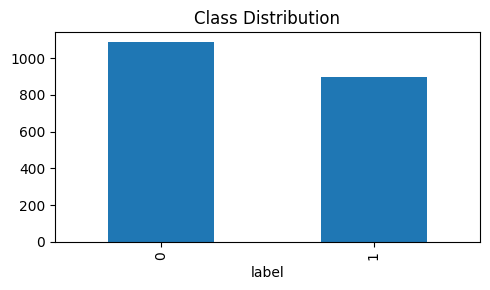

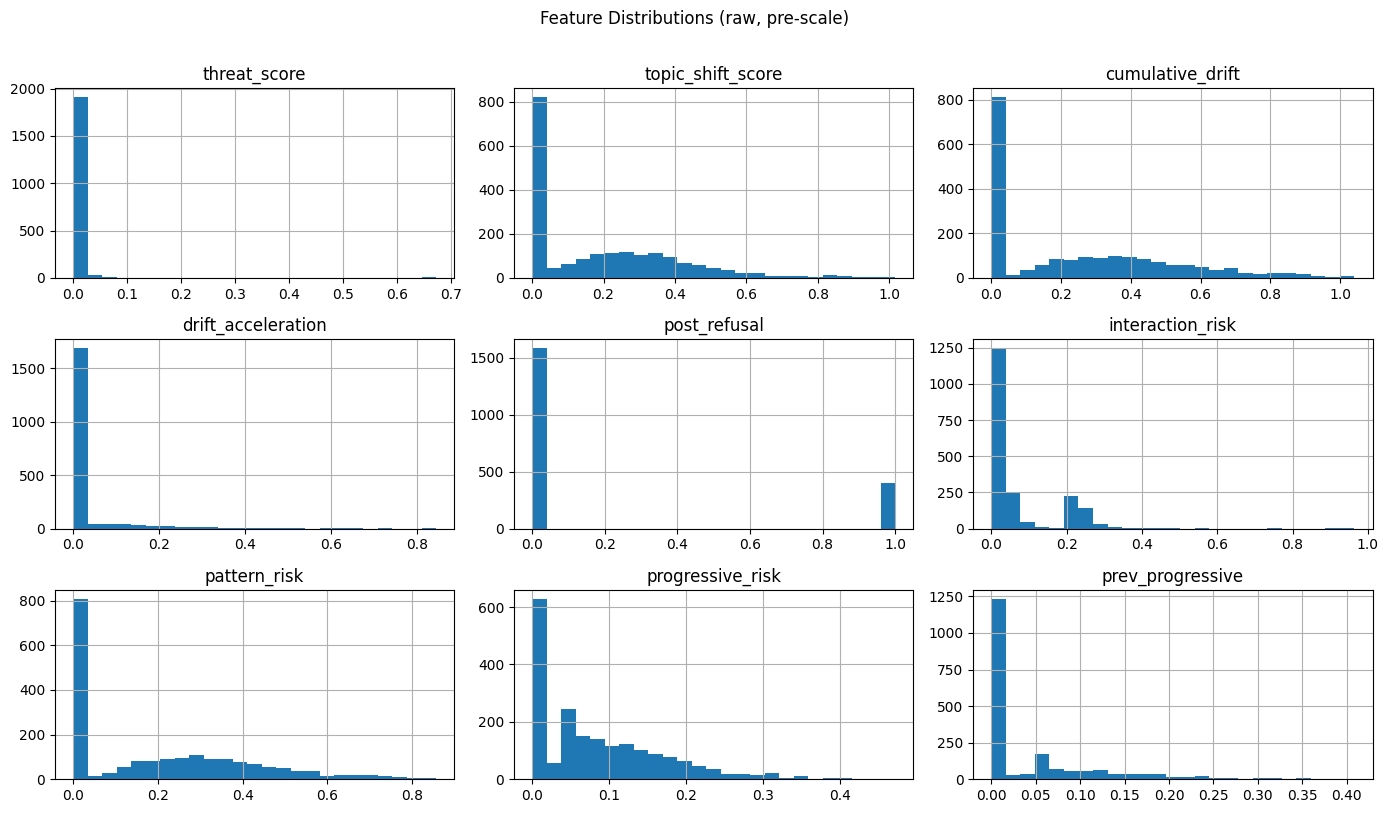

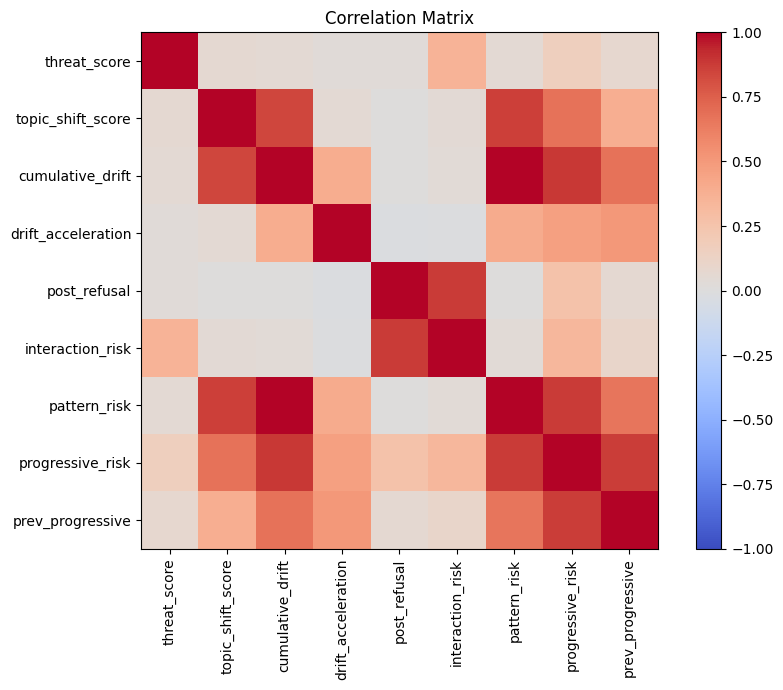

In [31]:

df_eda = recompute_risks(df, risk_calc).copy()
for col in ["toxicity_score", "threat_score"]:
    df_eda[col] = np.log1p(df_eda[col])

print(f"Shape: {df_eda.shape}")
print("\nMissing values:")
missing = df_eda.isna().sum()
print(missing[missing > 0] if missing.any() else "None")

print("\nClass distribution (label):")
print(df_eda["label"].value_counts(dropna=False))

df_eda["label"].value_counts().plot(kind="bar", figsize=(5, 3), title="Class Distribution")
plt.tight_layout(); plt.show()

num_cols = [c for c in df_eda.select_dtypes(include="number").columns if c != "label"]
df_eda[num_cols[3:]].hist(bins=25, figsize=(14, 8))
plt.suptitle("Feature Distributions (raw, pre-scale)", y=1.01)
plt.tight_layout(); plt.show()

corr = df_eda[num_cols[3:]].corr()
plt.figure(figsize=(9, 7))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout(); plt.show()


Good features:
                     score  abs_corr  mutual_info    f_score  rf_importance  \
pattern_risk      0.679280  0.144600     0.049301  42.326972       0.060554   
conv_id           0.650000  0.191390     0.000000  75.361052       0.186620   
cumulative_drift  0.647850  0.144588     0.044546  42.319911       0.062262   
progressive_risk  0.573109  0.123645     0.033855  30.771183       0.104186   

                       p_value  
pattern_risk      9.750800e-11  
conv_id           8.032218e-18  
cumulative_drift  9.785330e-11  
progressive_risk  3.292405e-08  

Weak features:
                       score  abs_corr  mutual_info    f_score  rf_importance  \
interaction_risk    0.272054  0.027319     0.015045   1.480285       0.125303   
prev_progressive    0.172762  0.074453     0.002621  11.048055       0.056979   
drift_acceleration  0.106783  0.072724     0.001017  10.538200       0.020005   
post_refusal        0.006132  0.031316     0.000000   1.945620       0.005760   

  

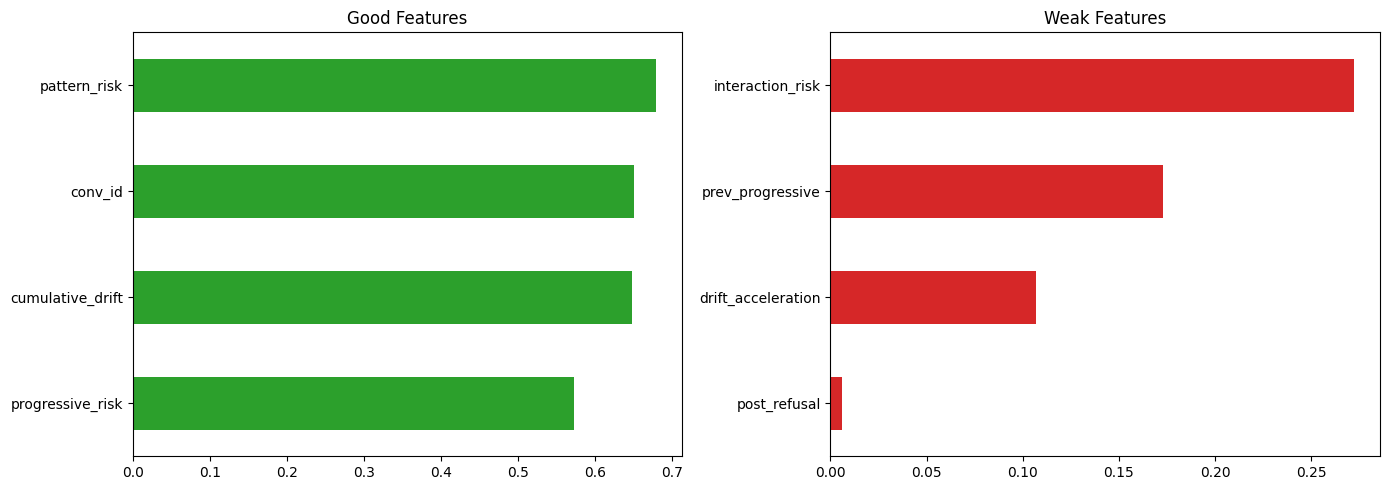

In [32]:
# Feature importance analysis (on unscaled EDA data)
target_col   = "label"
feature_cols_eda = [c for c in df_eda.select_dtypes(include=np.number).columns if c != target_col]

work = df_eda[[target_col] + feature_cols_eda].copy()
work[feature_cols_eda] = work[feature_cols_eda].fillna(work[feature_cols_eda].median())
work = work.dropna(subset=[target_col])

X_eda = work[feature_cols_eda]
y_eda = work[target_col].astype(int)

corr_scores = X_eda.apply(lambda c: c.corr(y_eda)).abs().fillna(0.0)
mi_scores   = pd.Series(mutual_info_classif(X_eda, y_eda, random_state=42), index=feature_cols_eda)
f_vals, p_vals = f_classif(X_eda, y_eda)
f_scores    = pd.Series(f_vals, index=feature_cols_eda).replace([np.inf, -np.inf], np.nan).fillna(0.0)
p_scores    = pd.Series(p_vals, index=feature_cols_eda).fillna(1.0)

rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_eda, y_eda)
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols_eda)

def minmax(s):
    s = s.astype(float); r = s.max() - s.min()
    return (s - s.min()) / r if r > 0 else pd.Series(0.0, index=s.index)

report = pd.DataFrame({
    "abs_corr": corr_scores, "mutual_info": mi_scores,
    "f_score": f_scores, "rf_importance": rf_importance, "p_value": p_scores,
})
report["score"] = (
    0.20 * minmax(report["abs_corr"]) +
    0.35 * minmax(report["mutual_info"]) +
    0.20 * minmax(report["f_score"]) +
    0.25 * minmax(report["rf_importance"])
)
report = report.sort_values("score", ascending=False)

strong_cutoff = report["score"].quantile(0.67)
weak_cutoff   = report["score"].quantile(0.33)
good = report[(report["score"] >= strong_cutoff) & (report["p_value"] <= 0.20)]
weak = report[(report["score"] <= weak_cutoff)   | ((report["mutual_info"] <= 1e-6) & (report["abs_corr"] < 0.03))]
if good.empty: good = report.head(max(1, len(report)//3))
if weak.empty: weak = report.tail(max(1, len(report)//3))

print("Good features:"); print(good[["score","abs_corr","mutual_info","f_score","rf_importance","p_value"]])
print("\nWeak features:"); print(weak[["score","abs_corr","mutual_info","f_score","rf_importance","p_value"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
good["score"].sort_values().plot(kind="barh", ax=axes[0], color="#2ca02c"); axes[0].set_title("Good Features")
weak["score"].sort_values().plot(kind="barh", ax=axes[1], color="#d62728"); axes[1].set_title("Weak Features")
plt.tight_layout(); plt.show()


## Models

In [33]:
# Logistic Regression
model_lr = LogisticRegression(class_weight="balanced", max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))
joblib.dump(model_lr, "final_TCA_classifier_lr.pkl")


=== Logistic Regression ===
[[141  77]
 [ 86  93]]
              precision    recall  f1-score   support

           0       0.62      0.65      0.63       218
           1       0.55      0.52      0.53       179

    accuracy                           0.59       397
   macro avg       0.58      0.58      0.58       397
weighted avg       0.59      0.59      0.59       397

ROC AUC: 0.60916918661268


['final_TCA_classifier_lr.pkl']

In [34]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
joblib.dump(xgb_model, "final_TCA_classifier_xgb.pkl")


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.61      0.62      0.61       218
           1       0.52      0.51      0.52       179

    accuracy                           0.57       397
   macro avg       0.56      0.56      0.56       397
weighted avg       0.57      0.57      0.57       397



['final_TCA_classifier_xgb.pkl']

In [22]:
# SVM (baseline)
svm_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))
joblib.dump(svm_model, "final_TCA_classifier_svm.pkl")


=== SVM ===
              precision    recall  f1-score   support

           0       0.66      0.55      0.60       218
           1       0.54      0.66      0.60       179

    accuracy                           0.60       397
   macro avg       0.60      0.60      0.60       397
weighted avg       0.61      0.60      0.60       397



['final_TCA_classifier_svm.pkl']

## Hyperparameter Tuning

In [23]:


X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42
)

recall_scorer = make_scorer(recall_score, pos_label=1)


In [24]:
# SVM grid search
param_grid_svm = {
    "C":      [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma":  ["scale", 0.001, 0.01, 0.1],
}
grid_svm = GridSearchCV(
    SVC(class_weight="balanced"),
    param_grid_svm,
    scoring=recall_scorer, cv=5, n_jobs=-1, verbose=1,
)
grid_svm.fit(X_train2, y_train2)

best_svm = grid_svm.best_estimator_
print("Best SVM params:", grid_svm.best_params_)
print(classification_report(y_val2, best_svm.predict(X_val2), zero_division=0))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best SVM params: {'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       265
           1       0.44      1.00      0.62       212

    accuracy                           0.44       477
   macro avg       0.22      0.50      0.31       477
weighted avg       0.20      0.44      0.27       477



In [25]:
# SVM with best params — evaluated on held-out test set
svm_tuned = SVC(kernel="rbf", class_weight="balanced", probability=True,
                random_state=42, gamma=0.01, C=0.1)
svm_tuned.fit(X_train, y_train)
print("=== SVM (tuned) on test set ===")
print(classification_report(y_test, svm_tuned.predict(X_test)))


=== SVM (tuned) on test set ===
              precision    recall  f1-score   support

           0       0.67      0.47      0.56       218
           1       0.53      0.72      0.61       179

    accuracy                           0.58       397
   macro avg       0.60      0.60      0.58       397
weighted avg       0.61      0.58      0.58       397



In [26]:
# XGBoost grid search
param_grid_xgb = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.01, 0.05, 0.1],
    "subsample":       [0.7, 0.8, 1.0],
    "colsample_bytree":[0.7, 0.8, 1.0],
    "gamma":           [0, 1, 5],
    "reg_alpha":       [0, 1, 5],
    "reg_lambda":      [1, 5, 10],
}
grid_xgb = GridSearchCV(
    XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1),
    param_grid_xgb,
    scoring=recall_scorer, cv=5, n_jobs=-1, verbose=1,
)
grid_xgb.fit(X_train2, y_train2)
best_xgb = grid_xgb.best_estimator_
print("Best XGB params:", grid_xgb.best_params_)
print(classification_report(y_val2, best_xgb.predict(X_val2), zero_division=0))


Fitting 5 folds for each of 6561 candidates, totalling 32805 fits
Best XGB params: {'colsample_bytree': 1.0, 'gamma': 5, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 5, 'reg_lambda': 10, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.65      0.67      0.66       265
           1       0.57      0.54      0.56       212

    accuracy                           0.61       477
   macro avg       0.61      0.61      0.61       477
weighted avg       0.61      0.61      0.61       477



In [ ]:

param_grid_lr = {
    "C":       [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear"],
}
grid_lr = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=1000),
    param_grid_lr,
    scoring=recall_scorer, cv=5, n_jobs=-1, verbose=1,
)
grid_lr.fit(X_train2, y_train2)
best_lr = grid_lr.best_estimator_
print("Best LR params:", grid_lr.best_params_)
print(classification_report(y_val2, best_lr.predict(X_val2), zero_division=0))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best LR params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.66      0.56      0.61       265
           1       0.54      0.64      0.59       212

    accuracy                           0.60       477
   macro avg       0.60      0.60      0.60       477
weighted avg       0.61      0.60      0.60       477



## Inference — run_model_on_conversation

In [29]:
# Use LR as the default inference model (swap out as needed)
model = model_lr

risk_calc_infer = RiskCalculator(
    alpha=Params['alpha'], beta=Params['beta'], gamma=Params['gamma'],
    inter_alpha=Params['inter_alpha'], inter_beta=Params['inter_beta'], inter_gamma=Params['inter_gamma'],
    pattern_alpha=Params['pattern_alpha'], pattern_beta=Params['pattern_beta'], pattern_gamma=Params['pattern_gamma'],
)

def run_model_on_conversation(conversation, model):
    rows       = []
    true_labels = []
    prev_user      = ""
    prev_assistant = ""
    prev_prog      = 0.0


    feature_extractor = FeatureExtractor(
        toxicity_model=toxicity_model,
        threat_model=threat_model,
        embedding_model=embedding_model,
        refusal_model=refusal_model,
    )

    for turn_id, turn in enumerate(conversation["turns"]):
        user_msg      = turn["attack_message"]
        assistant_msg = turn["target_response"]
        true_labels.append(turn["judge_result"])

        if turn_id == 0:
            features = feature_extractor.extract_features(
                user_msg="", assistant_msg="",
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )
        else:
            features = feature_extractor.extract_features(
                user_msg=prev_user, assistant_msg=prev_assistant,
                user_msg2=user_msg, assistant_msg2=assistant_msg,
            )

        row = {"turn_id": turn_id, **features}

        interaction = risk_calc_infer.compute_interaction_risk(row)
        pattern     = risk_calc_infer.compute_pattern_risk(row)
        progressive = risk_calc_infer.calculate_progressive_risk(row, prev_prog)

        row["interaction_risk"] = interaction
        row["pattern_risk"]     = pattern
        row["progressive_risk"] = progressive
        row["prev_progressive"] = prev_prog
        prev_prog = progressive

        # Apply log1p to match training transform
        for col in ["toxicity_score", "threat_score"]:
            row[col] = np.log1p(row[col])

        # Scale all 9 features using the fitted scaler
        X_input = pd.DataFrame([row])[model_feature_cols]
        X_input[model_feature_cols] = scaler.transform(X_input[model_feature_cols])

        row["pred"] = model.predict(X_input)[0]
        rows.append(row)

        prev_user      = user_msg
        prev_assistant = assistant_msg

    return pd.DataFrame(rows), true_labels


## Visualization

In [30]:
def plot_conversation(df, conv_id, tactic="Model Output"):
    fig, ax = plt.subplots(figsize=(10, 4))
    turn_ids = df["turn_id"].tolist()

    decision_color = {0: "#2ecc71", 1: "#e74c3c"}
    alpha_map      = {0: 0.10, 1: 0.18}
    for t, pred in zip(turn_ids, df["pred"]):
        ax.axvspan(t - 0.4, t + 0.4, color=decision_color[int(pred)], alpha=alpha_map[int(pred)])

    ax.plot(turn_ids, df["progressive_risk"],   "D-",  color="#2c3e50", linewidth=2,   label="progressive")
    ax.plot(turn_ids, df["interaction_risk"],   "o-",  color="#3498db", linewidth=1.5, label="interaction")
    ax.plot(turn_ids, df["pattern_risk"],       "s-",  color="#1abc9c", linewidth=1.5, label="pattern")
    ax.plot(turn_ids, df["cumulative_drift"],   "^--", color="#e74c3c", linewidth=1,   alpha=0.7, label="cumulative drift")
    ax.plot(turn_ids, df["drift_acceleration"], "x--", color="#c0392b", linewidth=1,   alpha=0.7, label="drift accel")

    ax.set_title(f"Conv {conv_id} | {tactic}", fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.05); ax.set_xticks(turn_ids)
    ax.set_xlabel("Turn"); ax.set_ylabel("Score"); ax.grid(True, alpha=0.25)

    line_handles = [
        plt.Line2D([0],[0], color="#2c3e50", marker="D", label="progressive"),
        plt.Line2D([0],[0], color="#3498db", marker="o", label="interaction"),
        plt.Line2D([0],[0], color="#1abc9c", marker="s", label="pattern"),
        plt.Line2D([0],[0], color="#e74c3c", marker="^", label="cumulative drift"),
        plt.Line2D([0],[0], color="#c0392b", marker="x", label="drift accel"),
    ]
    patch_handles = [
        mpatches.Patch(color="#2ecc71", alpha=0.4, label="ALLOW (0)"),
        mpatches.Patch(color="#e74c3c", alpha=0.4, label="BLOCK (1)"),
    ]
    ax.legend(handles=line_handles + patch_handles, loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()


Conv 0: toxic conversation detected


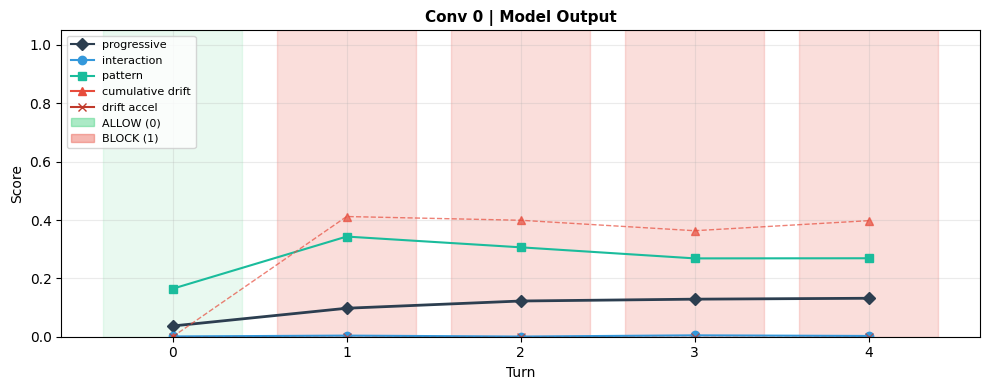

Conv 1: toxic conversation detected


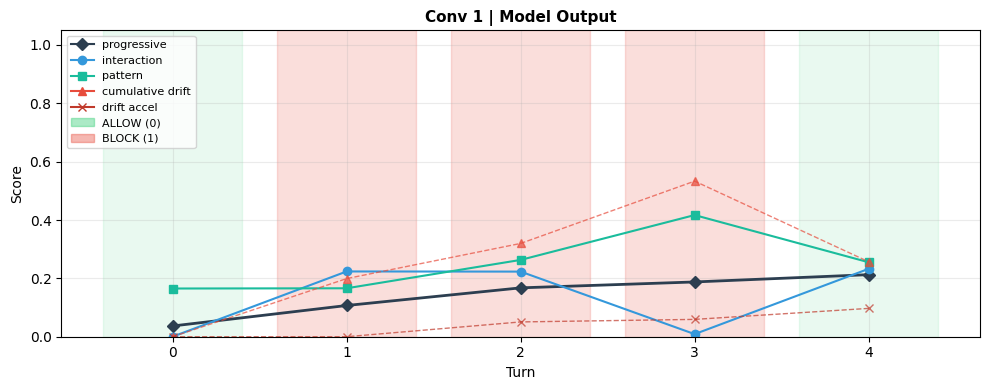

Conv 2: toxic conversation detected


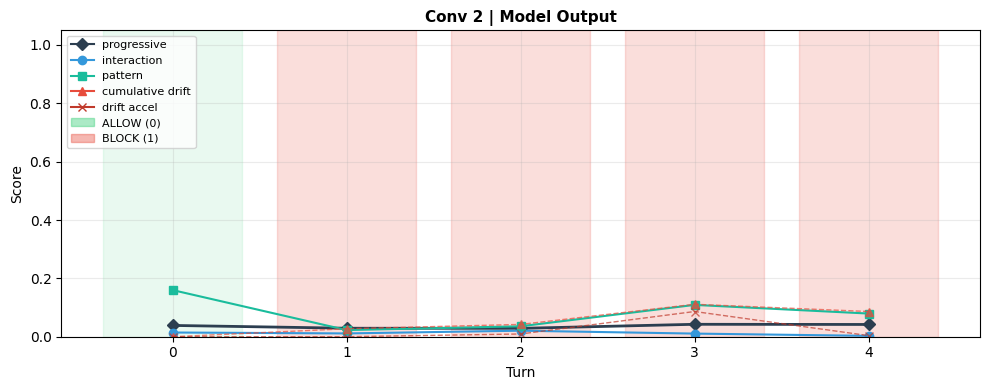

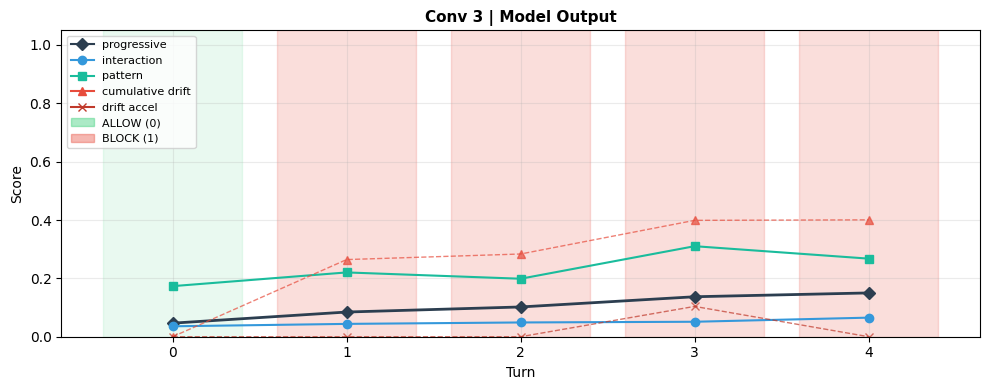

Conv 4: toxic conversation detected


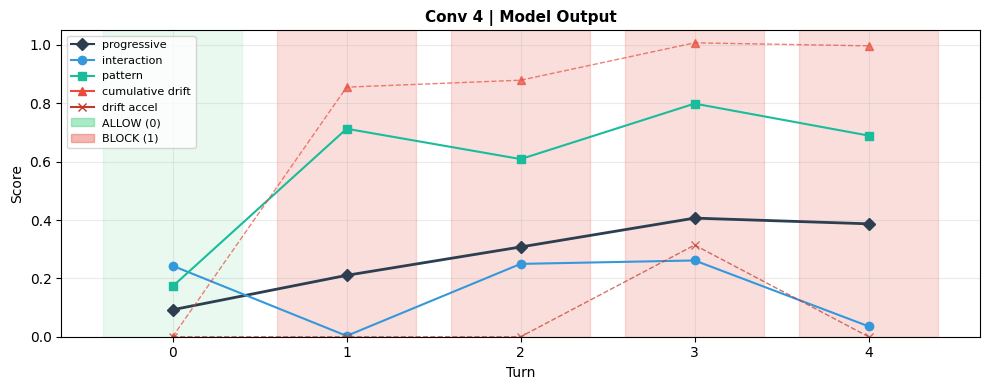

In [32]:

multi_turn_for_viz = [item for item in dataset_scaleai if len(item["turns"]) > 4]

for conv_id, convo in enumerate(multi_turn_for_viz[5:10]):
    df_conv, true_labels = run_model_on_conversation(convo, model)
    if 1 in true_labels:
        print(f"Conv {conv_id}: toxic conversation detected")
    plot_conversation(df_conv, conv_id)
